In [19]:
# Importing the python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV  
from sklearn.metrics import classification_report, confusion_matrix, precision_score, roc_auc_score

In [20]:
Modelling_Data = pd.read_csv(r"C:/Users/USER\Desktop/AMDARI/Fraudulent_Transaction_Detection_For_Finlora_Company/Fraudulent_Transaction_Detection_For_Finlora_Company/Finlora Dataset/artifacts/Engineering_Data.csv")  

In [21]:
Modelling_Data.head() 

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike,day_of_week,is_weekend
0,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,False,us,...,18,0,0,0,1,0,1,0,0,0
1,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,True,ca,...,20,0,0,0,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,False,us,...,23,0,0,0,1,0,1,0,0,0
3,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,2.22,False,us,...,1,0,0,0,1,0,1,0,1,0
4,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,3.61,False,us,...,9,0,0,0,1,0,1,0,1,0


In [22]:
# Drop timestamp before selecting categorical columns
categorical_features = (
    Modelling_Data
    .drop(columns=['timestamp'], errors='ignore')
    .select_dtypes(include=['object', 'bool', 'category'])
    .columns
) 

In [23]:
# Use 'number' to reliably capture int64, float64, etc.

numerical_features = (
    Modelling_Data
    .select_dtypes(include=['number'])
    .columns
    .drop(['is_fraud'], errors='ignore')
) 
 

In [24]:
all_features = list(categorical_features) + list(numerical_features)
print(all_features) 

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike', 'day_of_week', 'is_weekend']


Train_test Split & Preprocessing 
Data Partitioning Strategy: Executed an 80/20 time-based split after chronologically sorting the dataset by timestamp. Sorting before splitting prevents lookhead bias and simulates real-world fraud detection (training on historical transaction to predict future unseen transactions).

Sample Distribution
* Training Set: 8,584 records (80%)
* Testing Set: 2,147 records (20%)

Feature Transformation: Applied a ColumnTransaformer pipeline(StanardScaler for numerical features and OneHotEncoder for categorical features), expanding the features to 40 processed numerical columns.

Data Leakage Prevention: The transformation pipeline was fitted strictly on X_train and then X_ test.



In [25]:
# sorting by timestamp

Modelling_Data = Modelling_Data.sort_values(by='timestamp')


# 80/20 train_test split
split_index = int(len(Modelling_Data) * 0.8)  # This determine where the dataset should be split.
train_Modelling_Data = Modelling_Data.iloc[:split_index]  # training on past transaction
test_Modelling_Data = Modelling_Data.iloc[split_index:]    # testing on future transaction

# prepare X and y
X_train = train_Modelling_Data[all_features]
y_train = train_Modelling_Data['is_fraud']
X_test = test_Modelling_Data[all_features]
y_test = test_Modelling_Data['is_fraud'] 

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}") 


X_train: (8584, 28), y_train: (8584,)
X_test: (2147, 28), y_test: (2147,)


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Building preprocessing pipeline
preprecessor = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Fit on train, transform both
X_train_processed = preprecessor.fit_transform(X_train)
X_test_processed = preprecessor.transform(X_test)

print(f"Original features: {len(all_features)}") 
print(f"Processed features: {X_train_processed.shape[1]}")  


Original features: 28
Processed features: 40


In [28]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42, 
    max_iter=1000
)


In [29]:
# Build the complete pipeline
pipeline = Pipeline(
    steps=[
        ('preprecessor', preprecessor),
        ('classifier', lr_model)
    ]
)

# Train the pipeline
pipeline.fit(X_train, y_train)


# Make predictions
y_pred_lr = pipeline.predict(X_test)
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")   



Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1839
       Fraud       0.80      0.95      0.87       308

    accuracy                           0.96      2147
   macro avg       0.90      0.95      0.92      2147
weighted avg       0.96      0.96      0.96      2147


Confusion Matrix:
[[1766   73]
 [  16  292]]

ROC_AUC Score: 0.9835


Confusion Matrix for linear regression

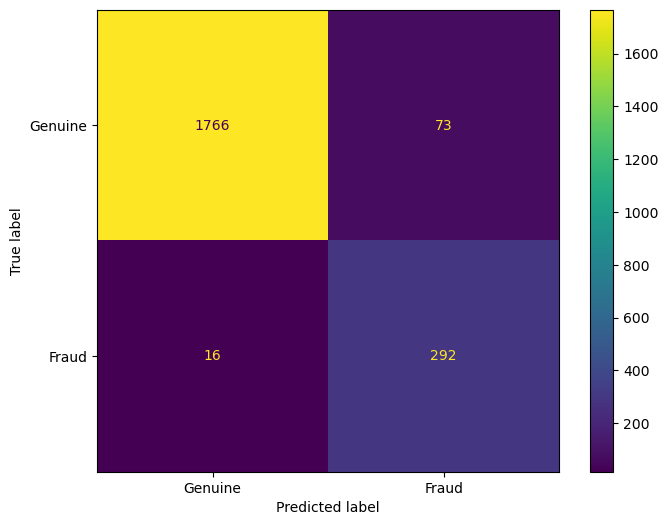

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay


# Calculate the matrix values first
cm_matrix = confusion_matrix(y_test, y_pred_lr)


# Display the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=['Genuine', 'Fraud'])
disp.plot(ax=ax, cmap='viridis')
plt.show()

Training Random forest with balanced class weight

In [36]:
# Create Random Forest model
rf_model = RandomForestClassifier(
  class_weight='balanced',
  random_state=42,
  n_estimators=100,
  max_depth=10,
  n_jobs=1  
)

# Build the complete pipeline
pipeline_rf = Pipeline(
    steps=[
        ('preprecessor', preprecessor),
        ('classifier', rf_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_rf.fit(X_train, y_train)


# Make predictioons
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}") 

Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1839
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2147
   macro avg       0.99      0.96      0.98      2147
weighted avg       0.99      0.99      0.99      2147


Confusion Matrix:
[[1839    0]
 [  25  283]]

ROC_AUC Score: 0.9738


Confusion Matrix for Random Forest

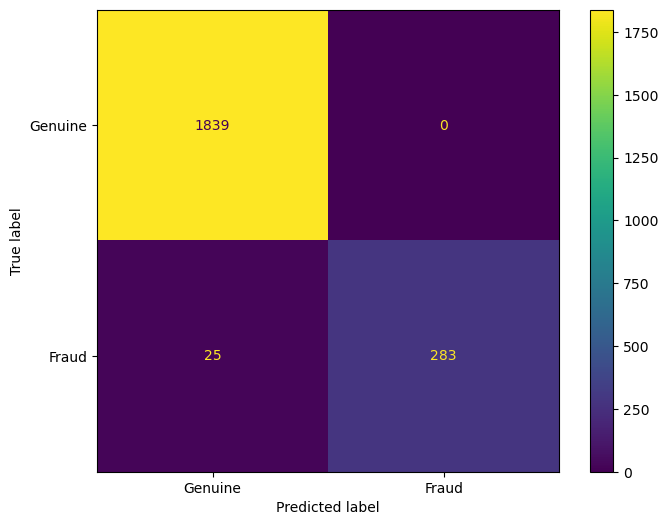

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay


# Calculate the matrix values first
cm_matrix = confusion_matrix(y_test, y_pred_rf)


# Display the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=['Genuine', 'Fraud'])
disp.plot(ax=ax, cmap='viridis')
plt.show()

In [ ]:
from xgboost import XGBClassifier

# Calculate scale pos weight for imbalance in xgboost classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Build the complete pipeline
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Result:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")



XGBoost Result:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1839
       Fraud       0.95      0.92      0.94       308

    accuracy                           0.98      2147
   macro avg       0.97      0.96      0.96      2147
weighted avg       0.98      0.98      0.98      2147


Confusion Matrix:
[[1825   14]
 [  25  283]]

ROC_AUC Score: 0.9673


Confusion matrix for xgboost

<Figure size 800x600 with 0 Axes>

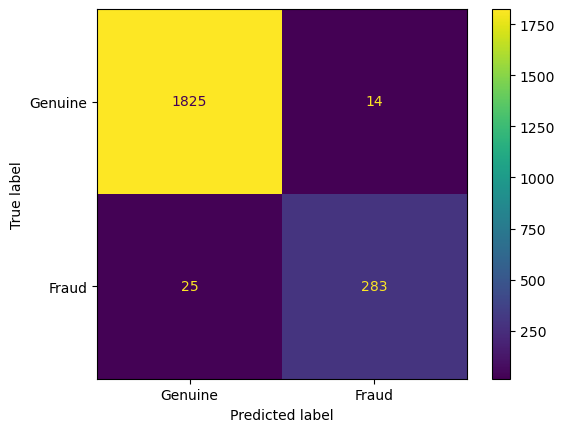

In [41]:
# import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb), 
    display_labels=["Genuine", "Fraud"],
)
plt.figure(figsize=(8, 6))
cm.plot()
plt.show()


SHAP ANALYSIS

Shap is a technique used to explain machine learning predictions - especialy complex models like tree ensembles-in a way that shows how each feature contributestoa decision.

SHAP answers this question: "Why did the model say this transaction is fraud?"

lt does this by assigning eacg feature a  contribution value (positive or negative) to the prediction. SHAP is used to interpret model prediction by quantifying the contribution of each feature to fraud risk. This enables transparency in actionable insights for fraud analysis and business stakeholders.

SHAP is based on Game Theory, specifically Shapleyvalues. it fairly distributes the "credit" of a prediction across features.

In [43]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the preprocessor from pipeline and transform raw X_test
X_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(X_test)


# Get the XGBoost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifier']

# Get booster and calculate SHAP values
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(X_test_processed)

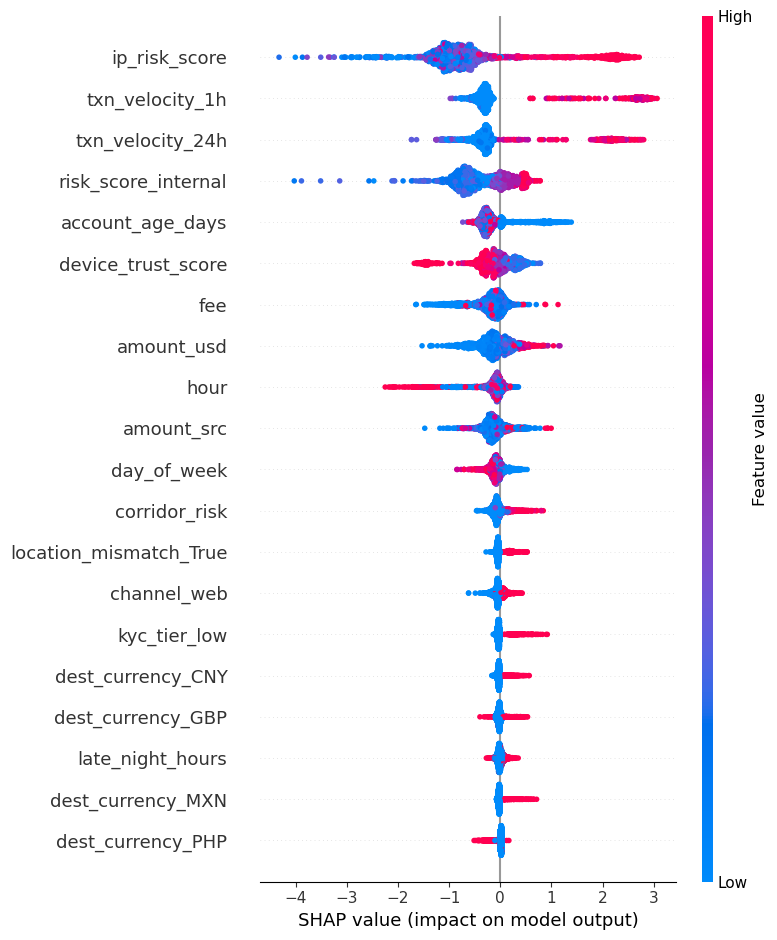

In [44]:
# Creating a clean feature name for the shap plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)
plt.show()

This is SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by important) while the X_axis shows the SHAP value(impact on prediction). The Blue color represent Low feature value while the color represents High feature value.

The Left part of the plot (negative SHAP value) pushes prediction toward Genuinue while the Right part (positie SHAP value) pushes prediction toward Fraud.

The SHAP beeswarm plot highlights that transaction veocity spikes, location mismatch, internal risk scores, and IP riskscores are the most influential rivers of fraud prediction. High values of these featurs consistently push predictionstoward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.

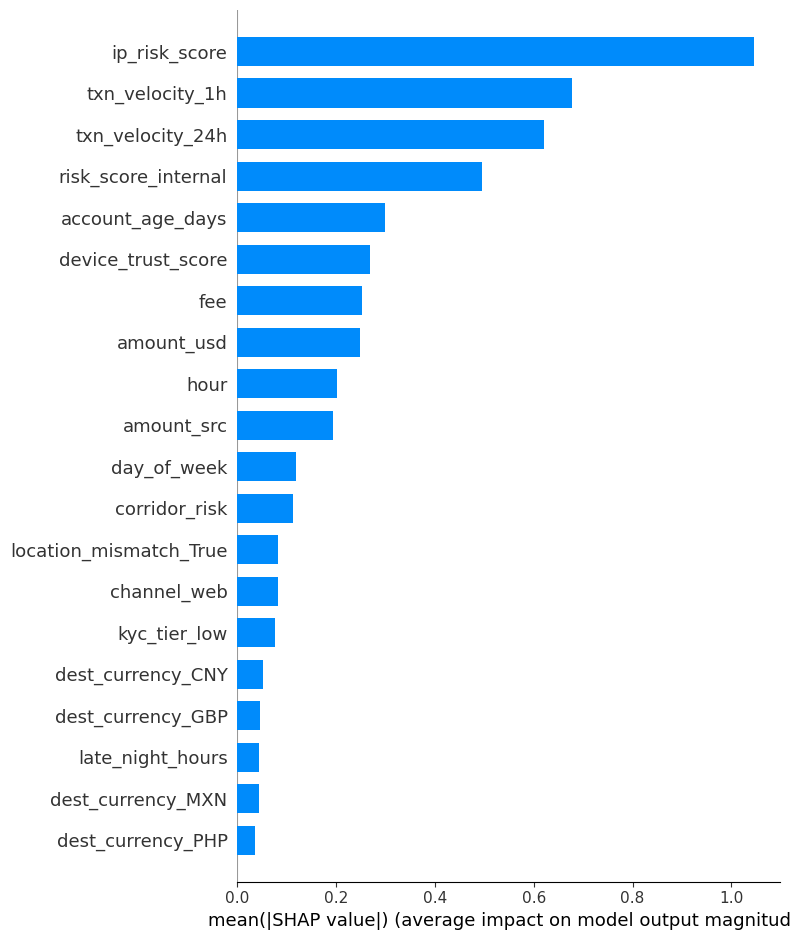

In [47]:
# Summary bar plot
shap.summary_plot(shap_values_gb, X_test_processed_df, plot_type="bar")
plt.show()


Model registering

In [ ]:
import dagshub
import mlflow
import lflow.sklearn
from sklearn.metrics import accuracy_score, precison_score, recall_score, f1_score, roc_auc_score


# Initialize DagsHub
dagshub.init(
    repo_owner='omowunmioyesola911',
    repo_name='Nordex-shift-optimization-system',
    mlflow=True
)

# Set experiment
